## Set up Gurobipy
---

In [11]:
# First you can check, whether the required packages are already installed
# (if not, you'll receive a warning)
%pip show gurobipy
%pip show matplotlib
%pip show numpy
%pip show pandas

Name: gurobipy
Version: 13.0.1
Summary: Python interface to Gurobi
Home-page: https://www.gurobi.com
Author: Gurobi Optimization, LLC
Author-email: 
License: Proprietary
Location: C:\Users\lstei\AppData\Roaming\Python\Python312\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Name: matplotlib
Version: 3.10.7
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analy

In [12]:
#%pip install gurobipy
#%pip install matplotlib
#%pip install numpy
#%pip install pandas

Import them into this notebook

In [13]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Budget-Constrained SALBP-2 with Human, Cobot & Humanoid
-----------------------------------------

*Budget-constrained extension of SALBP-2: each task can be performed by a **Human**, **Cobot** or **Humanoid** resource with a resource-dependent time and cost. We minimize the cycle time $C$ under a hard investment budget $B$.*

**Idea (presentation #2):** Each task can be performed by a different **resource type** $r \in \{$Human, Cobot, Humanoid$\}$ with a resource-dependent processing time $t_{ir}$ and cost. We minimize the cycle time $C$ subject to a hard **investment budget** $B$.

### New sets / parameters
$r \in \{$Human, Cobot, Humanoid$\}$ — resource types &nbsp;&nbsp; $t_{ir}$ — time of task $i$ with resource $r$ &nbsp;&nbsp; $H$ — horizon (h/yr) &nbsp;&nbsp; $B$ — budget &nbsp;&nbsp; $K_r = \text{invest}_r + \text{operating}_r \cdot H$

### New decision variables
$Y_{kr}=1$ if station $k$ is equipped with resource $r$ &nbsp;&nbsp; $S_{ikr}=1$ if task $i$ runs at station $k$ using resource $r$

### Objective &amp; constraints
$\min\ C$
1. $\sum_{k}\sum_{r} S_{ikr}=1\ \ \forall i$ &nbsp; (each task once)
2. $\sum_{k}\sum_{r} S_{ikr}\,k \le \sum_{k}\sum_{r} S_{jkr}\,k\ \ \forall (i,j)\in P$ &nbsp; (precedence)
3. $\sum_{i}\sum_{r} S_{ikr}\,t_{ir} \le C\ \ \forall k$ &nbsp; (cycle time)
4. $\sum_{r} Y_{kr}=1\ \ \forall k$ &nbsp; (one resource per station)
5. $S_{ikr} \le Y_{kr}\ \ \forall i,k,r$ &nbsp; (coupling)
6. $\sum_{k}\sum_{r} K_r Y_{kr} \le B$ &nbsp; (budget)


### Sets
---

In [14]:
Operations = [1,2,3,4,5,6,7,8,9]
Stations   = [1,2,3,4,5,6]
Resources  = ["Human", "Cobot", "Industrial", "Humanoid"]      # NEW: resource types r

N, M, R = len(Operations), len(Stations), len(Resources)

PrecRelations = [[1,3],[1,4],[2,4],[2,7],[3,5],[4,6],[7,6],[7,9],[5,8],[6,8],[6,9]]

### Processing-time matrix $t_{ir}$  (realistic, minutes)
Row = operation, column = [Human, Cobot, Humanoid]. Cobots are fast on heavy/repetitive tasks but slow on delicate ones; humanoids are fastest overall; humans are most flexible on delicate tasks.

In [ ]:
# Processing times [minutes].  Base = textbook human times of this instance.
# Heterogeneity (grounded in HRC literature, e.g. Weckenborg 2020, Dimeny & Koltai 2023):
#   Humanoid = fastest on all tasks (human-like flexibility + robotic endurance)
#   Cobot    = fast on heavy/repetitive, but SLOW on delicate/fine tasks (limited dexterity, fixed base)
#   Human    = flexible, best on delicate tasks, but slow on heavy ones
#        Human  Cobot  Humanoid
t = [
    [5.5,  5.0, 4.5,  4.0],   # op1  standard
    [7.4,  6.5, 4.0, 5.0],   # op2  long / standard
    [1.3,  3.0, 0.0, 1.8],   # op3  delicate  -> cobot slow
    [9.0,  6.0, 4.0, 4.5],   # op4  heavy     -> robots much faster
    [2.6,  4.5, 0.0, 2.8],   # op5  delicate  -> cobot slow
    [4.6,  4.0, 4.5, 3.2],   # op6  standard
    [8.0,  5.5, 3.5, 4.0],   # op7  heavy     -> robots much faster
    [4.5,  4.0, 4.5, 3.4],   # op8  standard
    [3.0,  4.0, 0.0, 2.6],   # op9  delicate  -> cobot slow
]

# Eligibility matrix E[i][r]: 1 if resource r can perform task i, 0 otherwise.
# Columns follow Resources = ["Human", "Cobot", "Humanoid"].
# This makes capability restrictions explicit instead of only using slower processing times.
# Example: final inspection is human-only; some heavy/delicate tasks cannot be performed by cobots.
elig = [
    [1, 1, 0, 1],   # op1
    [1, 0, 0, 1],   # op2
    [1, 1, 0, 1],   # op3
    [1, 0, 0, 1],   # op4
    [1, 0, 0, 1],   # op5
    [1, 1, 0, 1],   # op6
    [1, 0, 0, 1],   # op7
    [1, 1, 0, 1],   # op8
    [1, 0, 0, 0],   # op9: final inspection / judgement task
]

assert len(elig) == N and all(len(row) == R for row in elig), "Eligibility matrix must be N x R."

### Cost parameters & budget  (realistic 2025/26 figures)
$K_r = \text{invest}_r + \text{operating}_r \cdot H$

In [ ]:
# Cost parameters (every number traced to a source; see Quellen_Datengrundlage.xlsx)
H = 2000                                                        # planning horizon (h/year, ~1 shift)

# --- Acquisition / investment [EUR] (sourced) ---
investment = {"Human": 0, "Cobot": 75000, "Industrial": 120000, "Humanoid": 200000}
#   Cobot: cost model IJAMT 2023 + market;  Humanoid: Goldman Sachs (30-150k$ range)

# --- Operating cost per hour is DERIVED, not assumed: ---
#   operating = wage(human) + energy(power x elec_price) + maintenance(maint_rate x invest / H)
wage       = {"Human": 45, "Cobot": 0, "Industrial": 0, "Humanoid": 0}          # Human: Eurostat lc_lci_lev (DE ~45)
power_kW   = {"Human": 0.0, "Cobot": 0.35, "Industrial": 0.7, "Humanoid": 1.0}    # Cobot: UR10e datasheet; Humanoid: estimate
elec_price = 0.20                                              # EUR/kWh industrial, Eurostat nrg_pc_205 (DE 2024)
maint_rate = 0.10                                             # 10%/yr of investment (robot TCO literature, 5-10%)

operating = {r: wage[r] + power_kW[r]*elec_price + maint_rate*investment[r]/H for r in Resources}
# -> Human 45.0 ; Cobot ~2.82 ; Humanoid ~4.70  EUR/h

# K(r) = investment + operating * H   (first-year total cost of ownership)
#  -> Cobot ~60,640  <  Human 90,000  <  Humanoid ~99,400  EUR
Kcost = [investment[r] + operating[r]*H for r in Resources]
print("operating(EUR/h):", {r: round(operating[r],2) for r in Resources})
print("K(r):", dict(zip(Resources, [round(k) for k in Kcost])))

B = 480000        # annual resourcing budget EUR  (the knob to sweep for the frontier)

operating(EUR/h): {'Human': 45.0, 'Cobot': 2.82, 'Humanoid': 4.7}
K(r): {'Human': 90000, 'Cobot': 60640, 'Humanoid': 99400}


### Model as a function `build_and_solve(B)`
---
Wrapping the model in a function lets us re-solve for many budget levels to trace the time-cost frontier.

In [ ]:
def build_and_solve(B, silent=True):
    m = gp.Model("BudgetSALBP2")
    m.setParam("OutputFlag", 0)
    m.setParam("MIPGap", 0)

    # --- decision variables ---
    S = m.addVars(N, M, R, vtype=GRB.BINARY, name="S")   # task i at station k on resource r
    Y = m.addVars(M, R,    vtype=GRB.BINARY, name="Y")   # station k equipped with resource r
    C = m.addVar(lb=0, name="C")
    symBreak = m.addVar(lb=0, name="symBreak")

    # --- objective: minimize cycle time ---
    m.setObjective(C + symBreak, GRB.MINIMIZE)

    # (1) each task assigned exactly once (any station, any resource)
    m.addConstrs((quicksum(S[i,k,r] for k in range(M) for r in range(R)) == 1
                  for i in range(N)), name="assign")

    # (2) precedence (via station index)
    m.addConstrs((quicksum(S[i,k,r]*k for k in range(M) for r in range(R))
                  <= quicksum(S[j,k,r]*k for k in range(M) for r in range(R))
                  for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations),
                 name="prec")

    # (3) cycle time per station (resource-dependent time)
    m.addConstrs((quicksum(S[i,k,r]*t[i][r] for i in range(N) for r in range(R)) <= C
                  for k in range(M)), name="cycle")

    # (4) exactly one resource type per station
    m.addConstrs((quicksum(Y[k,r] for r in range(R)) == 1 for k in range(M)), name="oneRes")

    # (5) coupling: a task uses resource r only if the station is equipped with it
    m.addConstrs((S[i,k,r] <= Y[k,r]
                  for i in range(N) for k in range(M) for r in range(R)), name="couple")

    # (6) budget
    m.addConstr(quicksum(Kcost[r]*Y[k,r] for k in range(M) for r in range(R)) <= B, name="budget")

    # check eligibilty
    m.addConstrs(
        S[i,k,r] <= elig[i][r]
        for i in range(N)
        for k in range(M)
        for r in range(R)
    )

    # symmetry breaking (adapted to 3D)
    m.addConstr(symBreak >= quicksum(S[i,k,r]*k*(0.1**(i+1))
                for i in range(N) for k in range(M) for r in range(R)), name="sym")

    m.optimize()
    if m.status != GRB.OPTIMAL:
        return None
    cost = sum(Kcost[r]*round(Y[k,r].X) for k in range(M) for r in range(R))
    return m, S, Y, C, cost

### Single run & solution
---

In [18]:
res = build_and_solve(B)
if res is None:
    print("No solution (budget too small?)")
else:
    m, S, Y, C, cost = res
    print(f"Cycle Time C: {C.x:.2f}   |   used budget: {cost} EUR  (B={B})")
    for k in range(M):
        rk  = next(Resources[r] for r in range(R) if Y[k,r].X > 0.5)
        ops = [i+1 for i in range(N) for r in range(R) if S[i,k,r].X > 0.5]
        print(f"  Station {k+1} [{rk:8}] -> operations {ops}")

Cycle Time C: 6.80   |   used budget: 470720.0 EUR  (B=480000)
  Station 1 [Human   ] -> operations [1, 3]
  Station 2 [Cobot   ] -> operations [2]
  Station 3 [Cobot   ] -> operations [4]
  Station 4 [Humanoid] -> operations [5, 7]
  Station 5 [Humanoid] -> operations [6, 9]
  Station 6 [Cobot   ] -> operations [8]


### Time-Cost Frontier (sweep the budget)
---
This is the central result of the study (cf. Paper A): how much cycle time is gained per extra EUR of budget.

B=  372000:  C=8.50  used=363840.0
B=  410000:  C=8.00  used=402600.0
B=  450000:  C=7.20  used=431960.0
B=  500000:  C=6.50  used=480120.0
B=  550000:  C=6.00  used=518880.0
B=  600000:  C=6.00  used=596400.0


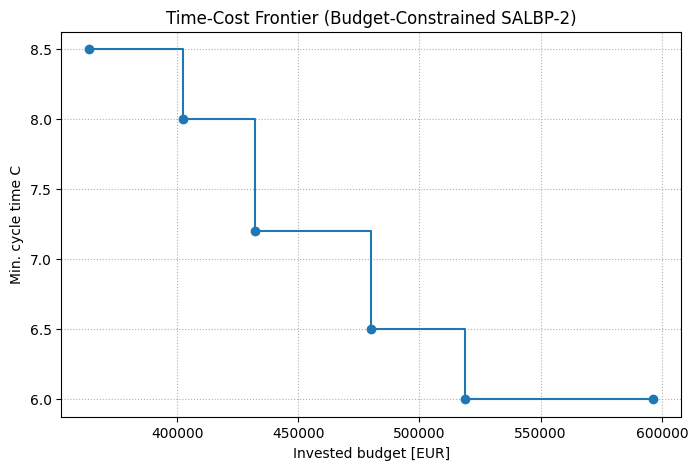

In [19]:
# feasible range: 6 stations x min K (all Cobot, 6x62k=372k) ... up to all Humanoid (6x100k=600k)
budgets = [372000, 410000, 450000, 500000, 550000, 600000]
front = []
for Bi in budgets:
    r = build_and_solve(Bi)
    if r:
        front.append((r[4], r[3].x))          # (used budget, C)
    print(f"B={Bi:>8}:  " + (f"C={r[3].x:.2f}  used={r[4]}" if r else "infeasible"))

if front:
    xs, ys = zip(*front)
    plt.figure(figsize=(8,5))
    plt.step(xs, ys, where="post", marker="o")
    plt.xlabel("Invested budget [EUR]"); plt.ylabel("Min. cycle time C")
    plt.title("Time-Cost Frontier (Budget-Constrained SALBP-2)")
    plt.grid(True, linestyle=":"); plt.show()

### Station utilization by resource
---

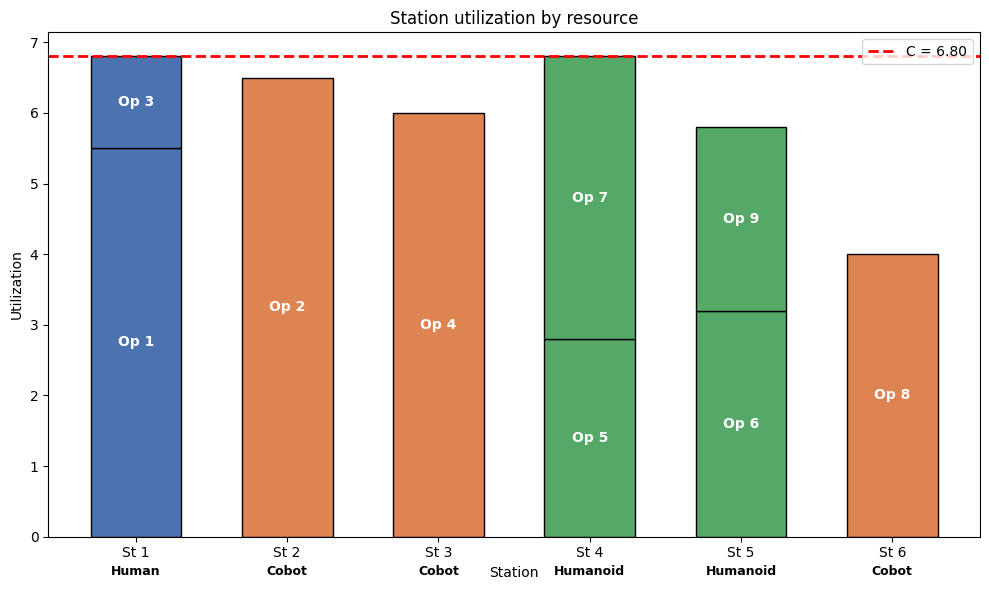

In [20]:
res = build_and_solve(B)
if res:
    m, S, Y, C, cost = res
    rescol = {"Human":"#4C72B0", "Cobot":"#DD8452", "Humanoid":"#55A868"}
    fig, ax = plt.subplots(figsize=(10,6)); bottoms = {k:0.0 for k in range(M)}
    for k in range(M):
        rk = next(Resources[r] for r in range(R) if Y[k,r].X > 0.5)
        for i in range(N):
            for r in range(R):
                if S[i,k,r].X > 0.5:
                    d = t[i][r]
                    ax.bar(k, d, bottom=bottoms[k], width=0.6,
                           color=rescol[rk], edgecolor='black')
                    ax.text(k, bottoms[k]+d/2, f'Op {i+1}', ha='center', va='center',
                            color='white', fontweight='bold')
                    bottoms[k] += d
        ax.text(k, -0.4, rk, ha='center', va='top', fontsize=9, fontweight='bold')
    ax.axhline(C.x, color='red', ls='--', lw=2, label=f'C = {C.x:.2f}')
    ax.set_xticks(range(M)); ax.set_xticklabels([f'St {k+1}' for k in range(M)])
    ax.set_xlabel('Station'); ax.set_ylabel('Utilization'); ax.legend()
    ax.set_title('Station utilization by resource'); plt.tight_layout(); plt.show()
else:
    print("No solution to visualize.")

### Notes & data sources
**Cost basis (2025/26):**
- Human: German labour cost ~45 EUR/h (Eurostat lc_lci_lev), no capital cost.
- Cobot: ~55,000 EUR (cost model IJAMT 2023 + market); operating derived = energy (UR10e 350W x 0.20 EUR/kWh, Eurostat) + maintenance (10% of capex/yr, robot TCO literature).
- Humanoid: ~90,000 EUR (Goldman Sachs, 30-150k$ range); operating derived = energy + maintenance (10% of capex/yr). Only the humanoid power draw (~1 kW) is a rough estimate (minor: ~0.2 EUR/h).
- Resulting annual K(r): **Cobot ~60.6k < Human 90k < Humanoid ~99.4k EUR** -> a real price gradient.

**Built-in trade-off:** the cheap cobot is slow on delicate tasks; the fast humanoid is the most
expensive -> more budget buys speed, so the time-cost frontier should now slope downward.

**Modelling switches:**
- Constraint (4) `== 1` forces every station to be equipped (and paid). Use `<= 1` to allow free empty stations.
- Capex is counted in full in year 1. For an annualized view, divide `investment` by a useful life (e.g. 8 years).
- Make a resource infeasible for a task by setting a very large time or fixing `S[i,k,r]=0`.

> I could not run Gurobi in this environment, so please execute the notebook once and check the
> frontier shape; if it is still flat, tighten the instance (fewer stations) or widen the time gap on the bottleneck tasks.
